In [5]:
import urllib.request
import pandas as pd

In [6]:
with urllib.request.urlopen("https://raw.githubusercontent.com/Somon8/social_graphs_25/main/final-project/folketinget_votings_enrichedv2.csv") as response:
    df_votings = pd.read_csv(response)

In [7]:
df_votings

,afstemning_id,afstemning_nummer,afstemning_konklusion,afstemning_vedtaget,afstemning_kommentar,afstemning_dato,afstemning_opdateringsdato,afstemning_typeid,møde_id,møde_dato,...,sag_titel,sag_titelkort,sag_resume,sag_nummer,sag_nummerprefix,sag_opdateringsdato,sag_typeid,sag_periodeid,sag_statusid,Period
0,1,411,"Vedtaget\n\n108 stemmer for forslaget (V, S, D...",True,NaN,NaN,2014-09-09T09:05:59.653,2,17,2014-09-09 09:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68
1,2,412,"Vedtaget\n\n98 stemmer for forslaget (V, S, DF...",True,NaN,NaN,2014-09-09T09:25:05.717,1,18,2014-09-09 09:15:00,...,Forslag til lov om ændring af virksomhedsskatt...,Om indgreb mod utilsigtet udnyttelse af virkso...,Loven ændrer virksomhedsskatteordningens regle...,L 200,L,2017-12-05T19:51:10.197,3.0,32.0,11.0,68
2,3,1,"Vedtaget\n\n59 stemmer for forslaget (S, RV, S...",True,NaN,NaN,2018-01-24T16:46:33.99,3,41,2012-10-04 10:00:00,...,"Folketinget konstaterer, at Danmark stod dårli...",Om rigets tilstand.,NaN,V 2,V,2018-01-24T16:45:02.127,9.0,31.0,17.0,68
3,4,7,"Vedtaget\n\n72 stemmer for forslaget (S, DF, R...",True,NaN,NaN,2018-01-25T10:25:25.64,1,156,2012-11-06 00:00:00,...,Forslag til lov om akutjob og jobpræmie til ar...,Om akutjob.,"Med loven etableres en midlertidig ordning, så...",L 46,L,2018-09-27T11:27:48.387,3.0,31.0,11.0,68
4,5,412,"Vedtaget\n\n98 stemmer for forslaget (V, S, DF...",True,NaN,NaN,2017-08-10T12:57:52.27,1,18,2014-09-09 09:15:00,...,Forslag til lov om ændring af virksomhedsskatt...,Om indgreb mod utilsigtet udnyttelse af virkso...,Loven ændrer virksomhedsskatteordningens regle...,L 200,L,2017-12-05T19:51:10.197,3.0,32.0,11.0,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10301,10378,533,"Vedtaget\nFor stemte 93 (S, V, DD, SF, LA, M, ...",True,Grundet en teknisk fejl kunne der ikke stemmes...,NaN,2025-09-30T14:56:15.043,1,15399,2025-09-30 13:00:00,...,Forslag til lov om ændring af lov om autorisat...,Om en kvoteordning for antallet af autorisatio...,"Lovforslaget etablerer en kvoteordning, der sk...",L 223,L,2025-10-07T08:18:28.087,3.0,163.0,11.0,71
10302,10379,2,"Vedtaget\nFor stemte 59 (S, V, M, JF, Jeppe Sø...",True,NaN,NaN,2025-10-10T11:45:43.137,3,15443,2025-10-09 08:00:00,...,"Folketinget konstaterer, at Danmark i de senes...",Om statsministerens åbningsredegørelse.,NaN,V 1,V,2025-10-13T13:55:54.783,9.0,165.0,17.0,71
10303,10380,3,"Forslaget er vedtaget\nFor stemte 56 (S, V og ...",True,NaN,NaN,2025-10-24T09:45:23.93,3,15446,2025-10-23 10:00:00,...,Minkkommissionen fik udleveret mange tusinde d...,Om regeringens håndtering af sagen om de slett...,NaN,V 6,V,2025-10-24T09:26:46.937,9.0,165.0,17.0,71
10304,10381,5,"Forslaget er vedtaget.\nFor stemte 96 (S, V, D...",True,Ved en fejl stemte Alex Ahrendtsen (DF) for fo...,NaN,2025-11-24T11:14:43.697,1,15454,2025-11-20 10:15:00,...,Forslag til lov om ændring af lov om kreditaft...,Om gennemførelse af det reviderede forbrugerkr...,Lovforslaget har til formål at gennemføre Euro...,L 19,L,2025-11-24T11:15:51.293,3.0,165.0,11.0,71


In [8]:
df_votings_type1 = df_votings[df_votings['afstemning_typeid'] == 1]

In [9]:
df_votings_type1 = df_votings_type1.copy()
df_votings_type1['topic_texts'] = df_votings_type1['sag_titel'] + " " + df_votings_type1['sag_resume'].fillna('')

In [ ]:
keywords = {
    'klima_miljø': [
        'klima', 'miljø', 'grøn', 'co2', 'klimaforandring', 'energi', 
        'vindmølle', 'solcelle', 'forurening', 'bæredygtig', 'affald', 
        'genanvendelse', 'natur', 'biodiversitet', 'emission', 'vedvarende'
    ],
    
    'sundhed': [
        'sundhed', 'vaccine', 'pandemi', 'covid', 'corona', 'medicin', 
        'sygehus', 'hospital', 'patient', 'læge', 'sygeplejerske', 'psykiatri',
        'apotek', 'sundhedsvæsen', 'behandling', 'sygdom'
    ],
    
    'uddannelse': [
        'uddannelse', 'skole', 'universitet', 'lærer', 'elev', 
        'studerende', 'undervisning', 'folkeskole', 'gymnasium',
        'erhvervsuddannelse', 'forskning', 'videregående'
    ],

    'skat': [
        'skat', 'afgift', 'moms', 'selskabsskat', 'fradrag', 
        'skattepligtig', 'indkomstskat', 'told', 'beskatning',
        'skattefradrag', 'skattelettelse', 'skattepligt'
    ],

    'erhverv': [
        'virksomhed', 'erhverv', 'konkurrence', 'iværksætter', 
        'selskab', 'marked', 'handel', 'eksport', 'import',
        'erhvervsliv', 'vækst', 'startup'
    ],

    'finans_budget': [
        'budget', 'finans', 'finanslov', 'udgift', 'bevilling',
        'statskasse', 'offentlig', 'udgiftspolitik', 'statsbudget'
    ],
    
    'arbejdsmarked_velfærd': [
        'arbejdsmarked', 'job', 'løn', 'pension', 'dagpenge', 'beskæftigelse',
        'kontanthjælp', 'overførsel', 'arbejdsløs', 'ledighed', 'fagforening',
        'barsel', 'sygedagpenge', 'efterløn', 'førtidspension', 'velfærd'
    ],
    
    'immigration': [
        'immigration', 'indvandring', 'asyl', 'flygtning', 
        'udlænding', 'opholdstilladelse', 'statsborgerskab', 
        'integration', 'familiesammenføring', 'visum', 'grænsekontrol',
        'udvisning', 'ophold', 'indrejse'
    ],
    
    'forsvar_sikkerhed': [
        'forsvar', 'militær', 'nato', 'våben', 'veteran', 'beredskab',
        'cyber', 'sikkerhed', 'terror', 'forsvaret', 'hær', 'flåde'
    ],
    
    'udenrigs_eu': [
        'eu', 'europa', 'udenrig', 'international', 'udviklingsbistand',
        'diplomati', 'ambassade', 'handelsaftale', 'union', 'grænse',
        'eksport', 'import', 'europæisk'
    ],
    
    'retspolitik': [
        'politi', 'kriminalitet', 'retsvæsen', 'straf', 'fængsel', 
        'domstol', 'dommer', 'retspleje', 'kriminel', 'forbrydelse',
        'vold', 'tyveri', 'anklage', 'dom'
    ],
    
    'transport_infrastruktur': [
        'transport', 'infrastruktur', 'vej', 'tog', 'kollektiv', 
        'metro', 'jernbane', 'cykel', 'trafik', 'lufthavn', 'bro',
        'motorvej', 'bil', 'kørsel'
    ],
    
    'bolig': [
        'bolig', 'husleje', 'ejendom', 'almen', 'lejlighed', 
        'boligstøtte', 'lejer', 'udlejer', 'andel', 'ejerbolig'
    ],
    
    'social_familie': [
        'social', 'børn', 'familie', 'ældre', 'handicap',
        'plejehjem', 'børnepasning', 'daginstitution', 'ældrepleje',
        'børnefamilie', 'adoption', 'forældremyndighed'
    ]
}

In [ ]:
"""
Folketinget Topic Classification Pipeline
=========================================
Classifies parliamentary cases by policy topic using stemmed keyword matching.
Produces exploratory statistics and visualizations.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.stem.snowball import SnowballStemmer
from collections import Counter
import re

# Initialize Danish stemmer
stemmer = SnowballStemmer("danish")


# =============================================================================
# STEMMING FUNCTIONS
# =============================================================================

def stem_word(word):
    """Stem a single Danish word"""
    return stemmer.stem(word.lower())

def stem_keyword_dict(keyword_dict):
    """Stem all keywords in the topic dictionary"""
    stemmed = {}
    for topic, words in keyword_dict.items():
        stemmed[topic] = list(set([stem_word(w) for w in words]))
    return stemmed

def tokenize_and_stem(text):
    """
    Tokenize Danish text and stem each token.
    Returns a list of stemmed tokens (with duplicates).
    """
    if pd.isna(text) or text is None:
        return []
    
    # Lowercase and extract Danish words (including æ, ø, å)
    tokens = re.findall(r'[a-zæøå]+', text.lower())
    
    # Stem each token
    stemmed = [stem_word(t) for t in tokens if len(t) > 2]  # Skip very short tokens
    
    return stemmed  # Return list - This was a set, but that would miss duplicates

# =============================================================================
# CLASSIFICATION FUNCTIONS
# =============================================================================

def classify_case(text, stemmed_keywords, use_substring=True):
    """
    Classify a case by counting keyword matches per topic.
    
    Parameters:
    -----------
    text : str
        The case description (resume + title)
    stemmed_keywords : dict
        Topic -> list of stemmed keywords
    use_substring : bool
        If True, also check for substring matches (helps with compound words)
    
    Returns:
    --------
    dict : topic -> match count
    """
    stemmed_tokens = tokenize_and_stem(text)  # Now a list
    
    scores = {}
    matched_keywords = {}
    
    for topic, stems in stemmed_keywords.items():
        matches = []
        
        for stem in stems:
            # Count occurrences
            count = stemmed_tokens.count(stem)
            if count > 0:
                matches.extend([stem] * count)  # Add stem 'count' times
            elif use_substring:
                for token in stemmed_tokens:
                    if len(stem) >= 4 and stem in token:
                        matches.append(f"{stem}(in:{token})")
        
        scores[topic] = len(matches)
        matched_keywords[topic] = matches
    
    return scores, matched_keywords

def assign_topics(scores, threshold=1):
    """
    Assign topic labels based on scores.
    
    Returns:
    --------
    primary_topic : str or None
        The highest-scoring topic (None if no matches)
    all_topics : list
        All topics meeting the threshold
    """
    # Filter to topics meeting threshold
    qualifying = {t: s for t, s in scores.items() if s >= threshold}
    
    if not qualifying:
        return None, []
    
    # Primary = highest score
    primary = max(qualifying, key=qualifying.get)
    all_topics = list(qualifying.keys())
    
    return primary, all_topics

# =============================================================================
# BATCH CLASSIFICATION
# =============================================================================

def classify_all_cases(df, text_column, stemmed_keywords, threshold=1):
    """
    Classify all cases in a DataFrame.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing cases
    text_column : str
        Name of column containing text to classify (e.g., 'resume' or combined)
    stemmed_keywords : dict
        Stemmed keyword dictionary
    threshold : int
        Minimum keyword matches to assign a topic
    
    Returns:
    --------
    pd.DataFrame : Original df with added classification columns
    """
    results = []
    
    for idx, row in df.iterrows():
        text = row[text_column]
        scores, matched = classify_case(text, stemmed_keywords)
        primary, all_topics = assign_topics(scores, threshold)
        
        results.append({
            'primary_topic': primary,
            'all_topics': all_topics,
            'topic_count': len(all_topics),
            'total_matches': sum(scores.values()),
            **{f'score_{t}': s for t, s in scores.items()}
        })
    
    result_df = pd.DataFrame(results)
    return pd.concat([df.reset_index(drop=True), result_df], axis=1)

# =============================================================================
# EXPLORATORY STATISTICS
# =============================================================================

def compute_coverage_stats(df):
    """Compute coverage statistics"""
    total = len(df)
    classified = (df['primary_topic'].notna()).sum()
    unclassified = (df['primary_topic'].isna()).sum()
    multi_topic = (df['topic_count'] > 1).sum()
    
    stats = {
        'total_cases': total,
        'classified': classified,
        'classified_pct': 100 * classified / total,
        'unclassified': unclassified,
        'unclassified_pct': 100 * unclassified / total,
        'multi_topic': multi_topic,
        'multi_topic_pct': 100 * multi_topic / total
    }
    
    return stats

def compute_topic_stats(df, topics):
    """Compute per-topic statistics"""
    stats = []
    
    for topic in topics:
        # Cases where this is primary topic
        primary_count = (df['primary_topic'] == topic).sum()
        
        # Cases where this topic appears at all
        any_count = df['all_topics'].apply(lambda x: topic in x if x else False).sum()
        
        # Average score when topic is present
        score_col = f'score_{topic}'
        if score_col in df.columns:
            avg_score = df[df[score_col] > 0][score_col].mean()
        else:
            avg_score = 0
        
        stats.append({
            'topic': topic,
            'primary_count': primary_count,
            'any_count': any_count,
            'avg_score_when_present': round(avg_score, 2) if not pd.isna(avg_score) else 0
        })
    
    return pd.DataFrame(stats).sort_values('primary_count', ascending=False)

def compute_overlap_matrix(df, topics):
    """Compute topic co-occurrence matrix"""
    matrix = pd.DataFrame(0, index=topics, columns=topics)
    
    for _, row in df.iterrows():
        if row['all_topics']:
            for t1 in row['all_topics']:
                for t2 in row['all_topics']:
                    if t1 in topics and t2 in topics:
                        matrix.loc[t1, t2] += 1
    
    return matrix

def compute_period_distribution(df, period_column, topics):
    """Compute topic distribution across periods"""
    # Cross-tabulation of primary topic by period
    crosstab = pd.crosstab(df[period_column], df['primary_topic'])
    
    # Ensure all topics are present
    for topic in topics:
        if topic not in crosstab.columns:
            crosstab[topic] = 0
    
    return crosstab[topics]

# =============================================================================
# VISUALIZATION FUNCTIONS
# =============================================================================

def plot_topic_distribution(topic_stats, figsize=(12, 6)):
    """Bar chart of cases per topic"""
    fig, ax = plt.subplots(figsize=figsize)
    
    topics = topic_stats['topic']
    counts = topic_stats['primary_count']
    
    bars = ax.bar(range(len(topics)), counts, color='steelblue', edgecolor='black')
    ax.set_xticks(range(len(topics)))
    ax.set_xticklabels(topics, rotation=45, ha='right')
    ax.set_ylabel('Number of Cases')
    ax.set_title('Cases per Topic (Primary Classification)')
    
    # Add count labels on bars
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                str(count), ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    return fig

def plot_overlap_heatmap(overlap_matrix, figsize=(10, 8)):
    """Heatmap of topic co-occurrence"""
    fig, ax = plt.subplots(figsize=figsize)
    
    # Normalize by diagonal (self-co-occurrence = topic count)
    # This shows proportion of overlap
    diag = np.diag(overlap_matrix.values)
    normalized = overlap_matrix.values / diag[:, np.newaxis]
    normalized = np.nan_to_num(normalized)  # Handle division by zero
    
    sns.heatmap(normalized, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=overlap_matrix.columns,
                yticklabels=overlap_matrix.index,
                ax=ax)
    ax.set_title('Topic Overlap Matrix\n(Row topic → proportion also in column topic)')
    plt.tight_layout()
    return fig

def plot_period_distribution(period_dist, figsize=(14, 6)):
    """Stacked area chart of topics over periods"""
    fig, ax = plt.subplots(figsize=figsize)
    
    period_dist.plot(kind='area', stacked=True, ax=ax, alpha=0.7)
    ax.set_xlabel('Period')
    ax.set_ylabel('Number of Cases')
    ax.set_title('Topic Distribution Across Parliamentary Periods')
    ax.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    return fig

def plot_match_strength_histogram(df, figsize=(10, 5)):
    """Histogram of keyword match counts"""
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Total matches
    axes[0].hist(df['total_matches'], bins=20, color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Total Keyword Matches')
    axes[0].set_ylabel('Number of Cases')
    axes[0].set_title('Distribution of Match Strength')
    axes[0].axvline(df['total_matches'].median(), color='red', linestyle='--', 
                    label=f"Median: {df['total_matches'].median():.0f}")
    axes[0].legend()
    
    # Topic count
    topic_counts = df['topic_count'].value_counts().sort_index()
    axes[1].bar(topic_counts.index, topic_counts.values, color='steelblue', edgecolor='black')
    axes[1].set_xlabel('Number of Topics Matched')
    axes[1].set_ylabel('Number of Cases')
    axes[1].set_title('Multi-Topic Classification')
    
    plt.tight_layout()
    return fig

# =============================================================================
# MAIN PIPELINE
# =============================================================================

def run_full_analysis(df, keywords, text_column, period_column=None, threshold=1, save_plots=True):
    """
    Run the complete topic classification and analysis pipeline.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with cases
    text_column : str
        Column containing text to classify
    period_column : str or None
        Column containing period identifier (optional)
    threshold : int
        Minimum matches to assign topic
    save_plots : bool
        Whether to save plots to files
    
    Returns:
    --------
    classified_df : pd.DataFrame
        DataFrame with classification results
    """
    print("=" * 60)
    print("FOLKETINGET TOPIC CLASSIFICATION PIPELINE")
    print("=" * 60)
    
    # Step 1: Stem keywords
    print("\nStemming keywords...")
    stemmed_keywords = stem_keyword_dict(keywords)
    topics = list(stemmed_keywords.keys())
    print(f"      {len(topics)} topics with {sum(len(v) for v in stemmed_keywords.values())} total stemmed keywords")
    
    # Step 2: Classify all cases
    print(f"\nClassifying {len(df)} cases...")
    classified_df = classify_all_cases(df, text_column, stemmed_keywords, threshold)
    print("      Done!")
    
    # Step 3: Compute statistics
    print("\nComputing statistics...")
    
    coverage = compute_coverage_stats(classified_df)
    print(f"\n      COVERAGE STATISTICS:")
    print(f"      Total cases:      {coverage['total_cases']}")
    print(f"      Classified:       {coverage['classified']} ({coverage['classified_pct']:.1f}%)")
    print(f"      Unclassified:     {coverage['unclassified']} ({coverage['unclassified_pct']:.1f}%)")
    print(f"      Multi-topic:      {coverage['multi_topic']} ({coverage['multi_topic_pct']:.1f}%)")
    
    topic_stats = compute_topic_stats(classified_df, topics)
    print(f"\n      TOPIC STATISTICS:")
    print(topic_stats.to_string(index=False))
    
    overlap = compute_overlap_matrix(classified_df, topics)
    
    period_dist = None
    if period_column and period_column in df.columns:
        period_dist = compute_period_distribution(classified_df, period_column, topics)
        print(f"\n      PERIOD DISTRIBUTION:")
        print(period_dist)
    
    # Step 4: Create visualizations
    print("\nCreating visualizations...")
    
    fig1 = plot_topic_distribution(topic_stats)
    fig2 = plot_overlap_heatmap(overlap)
    fig3 = plot_match_strength_histogram(classified_df)
    
    if period_dist is not None:
        fig4 = plot_period_distribution(period_dist)
    
    if save_plots:
        fig1.savefig('topic_distribution.png', dpi=150, bbox_inches='tight')
        fig2.savefig('topic_overlap.png', dpi=150, bbox_inches='tight')
        fig3.savefig('match_strength.png', dpi=150, bbox_inches='tight')
        if period_dist is not None:
            fig4.savefig('period_distribution.png', dpi=150, bbox_inches='tight')
        print("      Plots saved!")
    
    
    
    return classified_df

FOLKETINGET TOPIC CLASSIFICATION PIPELINE

Stemming keywords...
      14 topics with 179 total stemmed keywords

Classifying 5959 cases...
      Done!

Computing statistics...

      COVERAGE STATISTICS:
      Total cases:      5959
      Classified:       5668 (95.1%)
      Unclassified:     291 (4.9%)
      Multi-topic:      4594 (77.1%)

      TOPIC STATISTICS:
                  topic  primary_count  any_count  avg_score_when_present
                erhverv            714       2166                    1.58
            klima_miljø            625       1016                    1.63
                sundhed            567       1300                    1.58
                   skat            562        981                    1.97
             uddannelse            534       1030                    1.98
          finans_budget            469       1668                    1.43
            retspolitik            462       1473                    1.58
  arbejdsmarked_velfærd            418   

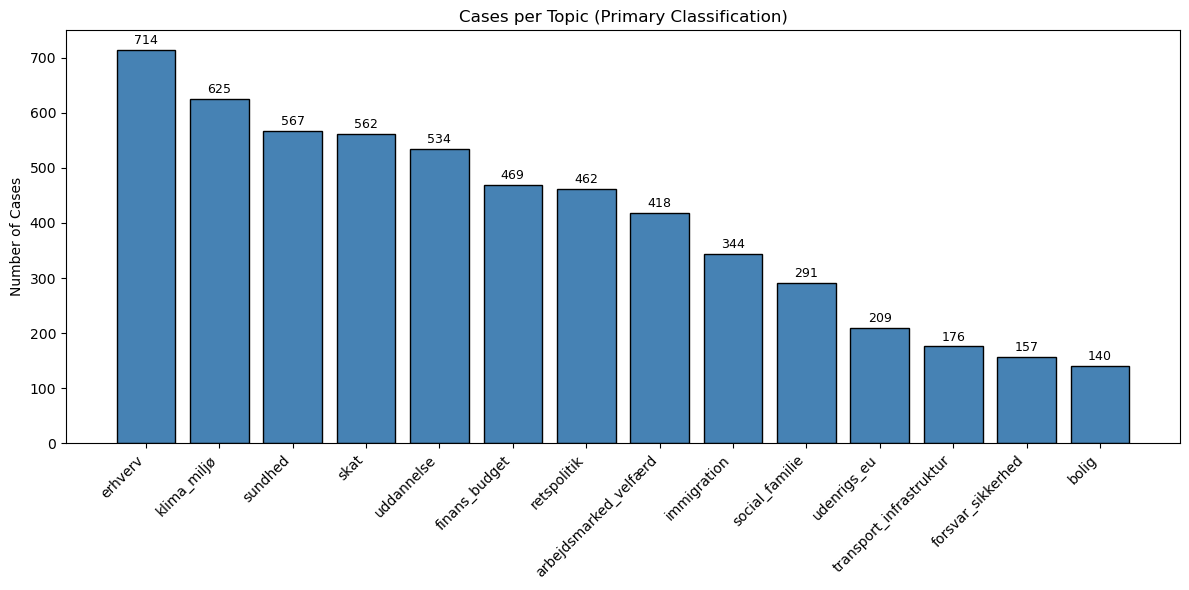

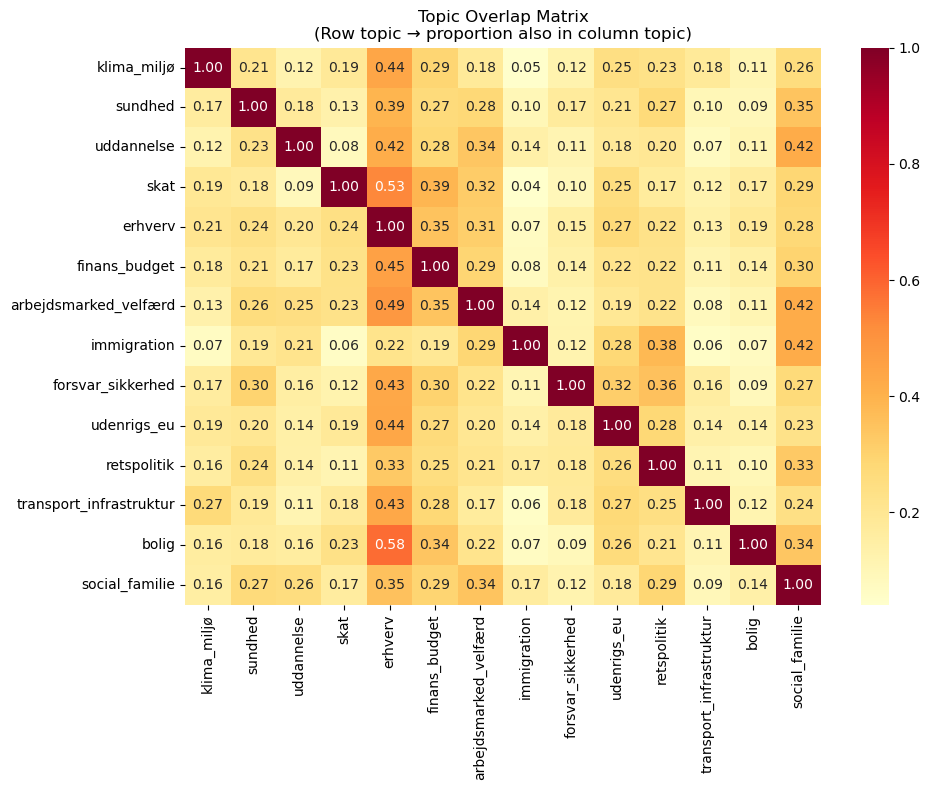

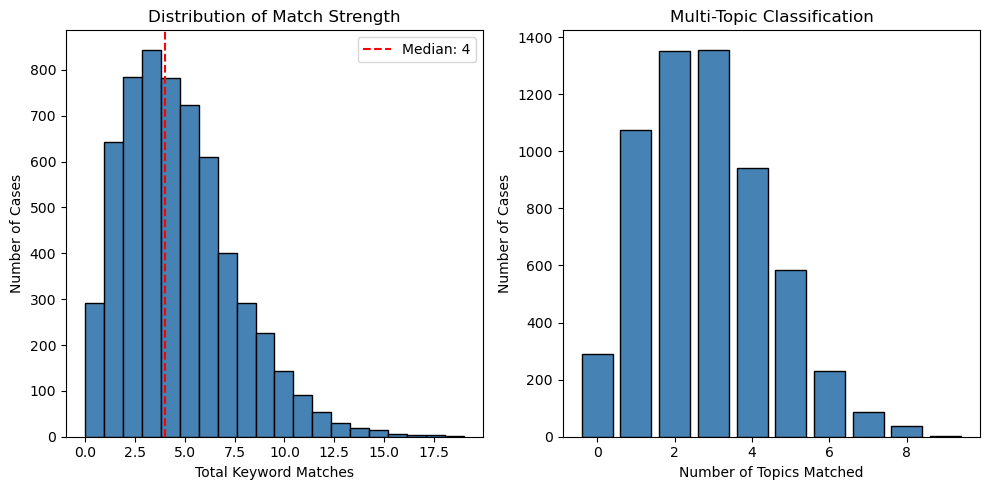

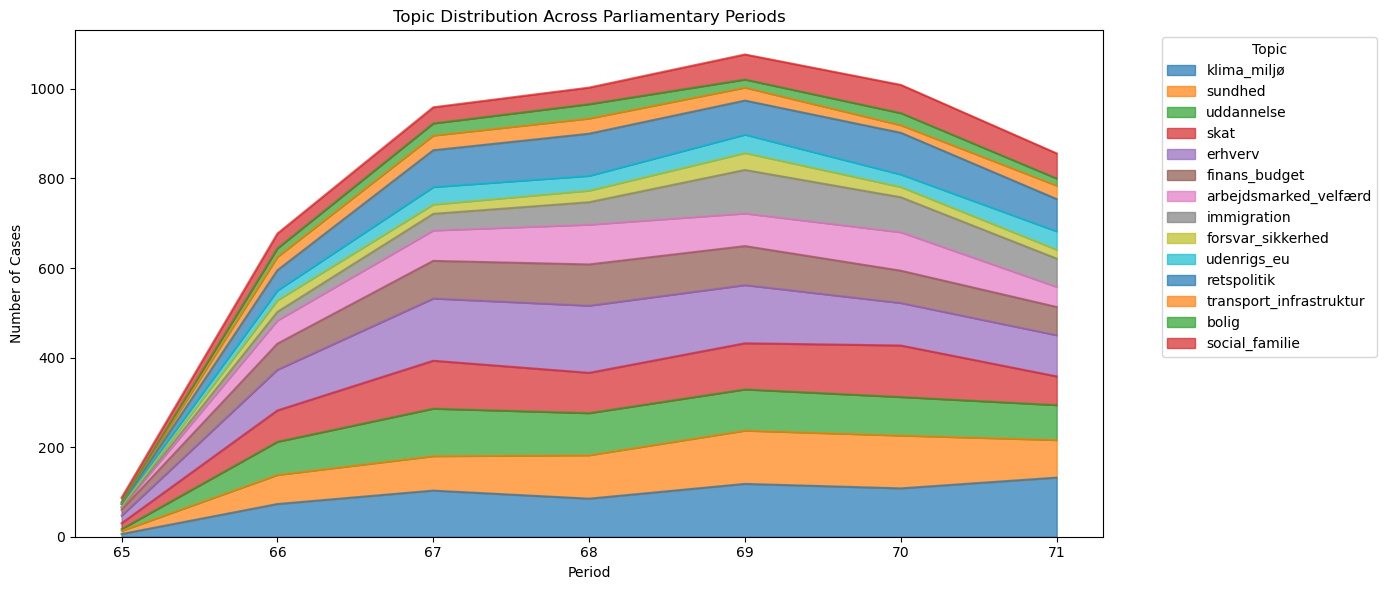

In [21]:
classified_df_raw_freq = run_full_analysis(
    df=df_votings_type1,
    keywords=keywords,
    text_column='topic_texts',  # Column with text data
    period_column='Period',  # Your period column name
    threshold=1,             # Minimum matches to assign topic
    save_plots=False
)


In [ ]:
classified_df.head()

In [ ]:
classified_df

In [ ]:
classified_df_raw_freq

In [23]:
import random

# Randomly pick 3 texts from each topic and display them with keyword statistics
topics = list(keywords.keys())
random.seed(1)

stemmed_keywords = stem_keyword_dict(keywords)
for topic in topics:
    # Filter cases where this topic is primary
    topic_cases = classified_df[classified_df['primary_topic'] == topic]
    
    if len(topic_cases) == 0:
        print(f"\n{'='*80}")
        print(f"TOPIC: {topic.upper()}")
        print(f"{'='*80}")
        print("No cases found for this topic")
        continue
    
    # Randomly sample up to 3 cases
    sample_size = min(3, len(topic_cases))
    sample_cases = topic_cases.sample(n=sample_size, random_state=42)
    
    print(f"\n{'='*80}")
    print(f"TOPIC: {topic.upper()} ({len(topic_cases)} total cases)")
    print(f"{'='*80}")
    
    for idx, (_, row) in enumerate(sample_cases.iterrows(), 1):
        print(f"\n[Case {idx}] (ID: {row['sag_id']}) {row['sag_titel']} ")
        print(f"  Resume: {row['sag_resume'][:100] if pd.notna(row['sag_resume']) else 'N/A'}...")
        
        # Get score for this topic
        score_col = f'score_{topic}'
        score = row[score_col]
        total_matches = row['total_matches']
        
        print(f"  Keyword matches: {score}/{total_matches} total matches")
        # Get the stemmed keywords for this topic
        stemmed_topic_keywords = stemmed_keywords[topic]

        # Tokenize and stem the text
        text_tokens = tokenize_and_stem(row['topic_texts'])

        # Find which keywords matched
        matched_words = [kw for kw in stemmed_topic_keywords if kw in text_tokens]
        print(f"  Matched keywords: {', '.join(matched_words) if matched_words else 'None'}")
        print(f"  All topics: {row['all_topics']}")


TOPIC: KLIMA_MILJØ (625 total cases)

[Case 1] (ID: 88405.0) Forslag til lov om ændring af lov om fremme af vedvarende energi, biobrændstofloven, lov om naturgasforsyning og forskellige andre love (Gennemførelse af dele af direktiv om fremme af anvendelsen af energi fra vedvarende energikilder, herunder bestemmelser om oprindelsesgarantier, tilladelsesprocesser, VE-fællesskaber, bæredygtighedskriterier og kriterier for drivhusgasemissionsbesparelser for biobrændstoffer, biomassebrændsler og flydende biobrændsler, m.v.) 
  Resume: Lovforslagets hovedformål er at understøtte, at brugen af træbiomasse til el og varme er så bæredygt...
  Keyword matches: 6/11 total matches
  Matched keywords: vedvar, bæredyg, energi, klima
  All topics: ['klima_miljø', 'immigration', 'forsvar_sikkerhed', 'udenrigs_eu', 'transport_infrastruktur', 'social_familie']

[Case 2] (ID: 91376.0) Forslag til folketingsbeslutning om, at offentlig energiplanlægning tilrettelægges ud fra, at atomkraft kan anvendes. 
 